# Problem Statement 1:-->

A glass manufacturing plant uses different earth elements to design new glass materials based on customer requirements. For that, they would like to automate the process of classification as it’s a tedious job to manually classify them. Help the company achieve its objective by correctly classifying the glass type based on the other features using KNN algorithm.

Business Objectives:

The business objective is to automate the classification of glass types based on various features.
    

Any Constraints: 

Yes, there is several constraints that should be considered such as, quality of data, imbalanced data, feature scalig, etc.

In [20]:
#import required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
#Load the dataset
glass=pd.read_csv("F:/Data science/Assignments/diwali_assignment/glass.csv")

In [4]:
glass.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [5]:
#seprating the features(X) and target variable (y)
X=glass.iloc[:,:-1]  #all col except last one
y=glass.iloc[:,-1] #the last col is a target

In [10]:
#Normalizing the data using MinMaxScaler
scaler=MinMaxScaler()
X_scaled=scaler.fit_transform(X)

In [11]:
#spliting the dataset into training and testing dataset
X_train, X_test, y_train, y_test=train_test_split(X_scaled, y,test_size=0.2, random_state=42,stratify=y)

In [15]:
#choose the value of k 
acc=[]
k_values=range(3,50,2)
for k in k_values:
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_acc=knn.score(X_test, y_test)
    test_acc = knn.score(X_test, y_test)
    acc.append([train_acc, test_acc])

C:\Users\Sai\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\Sai\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` t

C:\Users\Sai\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\Sai\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` t

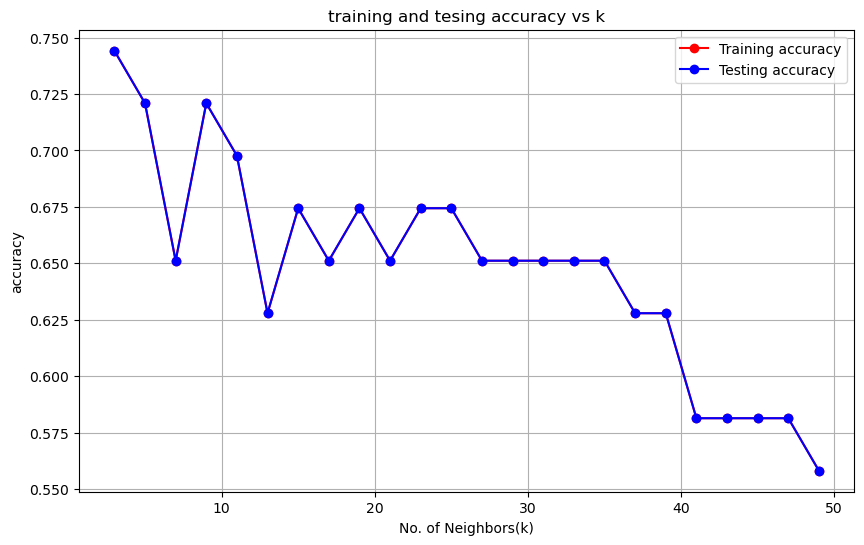

In [16]:
#plotting training and tesing accuracy for different k values
plt.figure(figsize=(10,6))
plt.plot(k_values, [i[0] for i in acc],'ro-', label='Training accuracy')
plt.plot(k_values, [i[1] for i in acc], 'bo-', label='Testing accuracy')
plt.xlabel("No. of Neighbors(k)")
plt.ylabel("accuracy")
plt.title("training and tesing accuracy vs k")
plt.legend()
plt.grid()
plt.show()

In [17]:
#selecting optimal k
optimal_k=9
knn= KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=9)

In [18]:
#making predictions
y_pred = knn.predict(X_test)

C:\Users\Sai\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [21]:
#evalating the model
print(f"Accuracy for K={optimal_k}: {accuracy_score(y_test, y_pred)}")

Accuracy for K=9: 0.7209302325581395


In [23]:
print("Classification report: ")
print(classification_report(y_test, y_pred))

Classification report: 
              precision    recall  f1-score   support

           1       0.72      0.93      0.81        14
           2       0.69      0.73      0.71        15
           3       0.00      0.00      0.00         3
           5       0.50      0.33      0.40         3
           6       1.00      0.50      0.67         2
           7       0.83      0.83      0.83         6

    accuracy                           0.72        43
   macro avg       0.62      0.55      0.57        43
weighted avg       0.67      0.72      0.69        43



C:\Users\Sai\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Sai\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Sai\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [24]:
print("Confussion matrix: ",confusion_matrix(y_test, y_pred))

Confussion matrix:  [[13  1  0  0  0  0]
 [ 3 11  0  1  0  0]
 [ 2  1  0  0  0  0]
 [ 0  1  0  1  0  1]
 [ 0  1  0  0  1  0]
 [ 0  1  0  0  0  5]]


In [26]:
#misclassification
misclassifications=(y_test != y_pred).sum()
print("No. of misclassification: ",misclassifications)

No. of misclassification:  12


Model output explanation:--->

The KNN(k-nearest neighbors) model predicts the type of glass based on chemical composition features.

After training the model on normalized data, it evalate the performance using testing data.

key output includes:

Accuracy-->higher accrancy reflaects better performance

classification report-->This helps to understand how well the model perform for each class.

Confusion matrix-->helping identify misclassifications.

Optimal K Selection--> Through testing different values of K, the graph identifies the K value that provides the best balance between training and testing accuracy.

Benefits of this solution-->

By implementing this solution, the company can streamline its operations, reduce costs, and improve customer satisfaction.

# Problem Statement 2-->

A National Zoopark in India is dealing with the problem of segregation of the animals based on the different attributes they have. Build a KNN model to automatically classify the animals. Explain any inferences you draw in the documentation.

Business Objectives:

The business objective is to automate the classification of animal types based on various features.

Any Constraints: 

Yes, there is several constraints that should be considered such as, dataset constraints, KNN Algorithm Constraints(choice of k) etc.

In [41]:
#import required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [28]:
#load dataset
zoo=pd.read_csv("F:/Data science/Assignments/diwali_assignment/Zoo.csv")

In [29]:
print(zoo.describe())

             hair    feathers        eggs        milk    airborne     aquatic  \
count  101.000000  101.000000  101.000000  101.000000  101.000000  101.000000   
mean     0.425743    0.198020    0.584158    0.405941    0.237624    0.356436   
std      0.496921    0.400495    0.495325    0.493522    0.427750    0.481335   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      0.000000    0.000000    1.000000    0.000000    0.000000    0.000000   
75%      1.000000    0.000000    1.000000    1.000000    0.000000    1.000000   
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   

         predator     toothed    backbone    breathes    venomous        fins  \
count  101.000000  101.000000  101.000000  101.000000  101.000000  101.000000   
mean     0.554455    0.603960    0.821782    0.792079    0.079208    0.168317   
std      0.499505    0.4915

In [48]:
zoo.head(5)

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,0
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,0
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,3
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,0
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,0


In [50]:
#drop the 'animal name' column it is non-numeric
zoo= zoo.drop('animal name', axis=1)

In [52]:
#split the dataset into features (X) and target (y)
X = zoo.drop('type', axis=1)  # Features
y = zoo['type']  # Target variable

In [53]:
#Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [71]:
#Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [72]:
#train KNN model
knn = KNeighborsClassifier(n_neighbors=3)  #K=3 
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [73]:
#make predictions
y_pred = knn.predict(X_test)

C:\Users\Sai\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [74]:
#evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[15  0  0  0  0  0  0]
 [ 0  3  0  0  0  0  0]
 [ 0  0  0  1  0  0  0]
 [ 0  0  0  2  0  0  0]
 [ 0  0  0  0  2  0  0]
 [ 0  0  0  0  0  5  0]
 [ 0  0  0  0  0  1  2]]


In [75]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         3
           2       0.00      0.00      0.00         1
           3       0.67      1.00      0.80         2
           4       1.00      1.00      1.00         2
           5       0.83      1.00      0.91         5
           6       1.00      0.67      0.80         3

    accuracy                           0.94        31
   macro avg       0.79      0.81      0.79        31
weighted avg       0.92      0.94      0.92        31



C:\Users\Sai\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Sai\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Sai\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [76]:
#print accuracy
accuracy = knn.score(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")  #accracy * 100 convert accuracy into percentage and .2f -->format no. to two decimal places

Test Accuracy: 93.55%


C:\Users\Sai\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


model output explanation-->

First we preprocess the dataset. Then feature scaling, model training Then done model evalation.

Benefits of this solution-->

The KNN model helps classify animals into different types based on their attributes (e.g., whether they have hair, whether they lay eggs, etc.)